In [561]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [562]:
df = pd.read_csv("04-penguins_lter.csv")

In [563]:
df.head()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


In [564]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    str    
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    str    
 3   Region               344 non-null    str    
 4   Island               344 non-null    str    
 5   Stage                344 non-null    str    
 6   Individual ID        344 non-null    str    
 7   Clutch Completion    344 non-null    str    
 8   Date Egg             344 non-null    str    
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  334 non-null    str    
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o/oo)    331 non-null    float64
 16  C

In [ ]:
df.drop(["Comments","Delta 13 C (o/oo)","Delta 15 N (o/oo)","Sex","Date Egg","Clutch Completion","Individual ID","Stage","Island","Region","Sample Number","studyName"],axis=1,inplace=True)
df.head()
# İşimize pek yaramıycağını düşündüğüm satırları dropladım.

,Species,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
0,Adelie Penguin (Pygoscelis adeliae),39.1,18.7,181.0,3750.0
1,Adelie Penguin (Pygoscelis adeliae),39.5,17.4,186.0,3800.0
2,Adelie Penguin (Pygoscelis adeliae),40.3,18.0,195.0,3250.0
3,Adelie Penguin (Pygoscelis adeliae),NaN,NaN,NaN,NaN
4,Adelie Penguin (Pygoscelis adeliae),36.7,19.3,193.0,3450.0


In [566]:
df.isna().sum()

Species                0
Culmen Length (mm)     2
Culmen Depth (mm)      2
Flipper Length (mm)    2
Body Mass (g)          2
dtype: int64

In [ ]:
df.dropna(inplace=True)
# Na olan 2 satır vardı onlarıda dropladık
df.isna().sum()

Species                0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
dtype: int64

In [568]:
df.info()

<class 'pandas.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              342 non-null    str    
 1   Culmen Length (mm)   342 non-null    float64
 2   Culmen Depth (mm)    342 non-null    float64
 3   Flipper Length (mm)  342 non-null    float64
 4   Body Mass (g)        342 non-null    float64
dtypes: float64(4), str(1)
memory usage: 16.0 KB


In [569]:
df["Species"].value_counts()

Species
Adelie Penguin (Pygoscelis adeliae)          151
Gentoo penguin (Pygoscelis papua)            123
Chinstrap penguin (Pygoscelis antarctica)     68
Name: count, dtype: int64

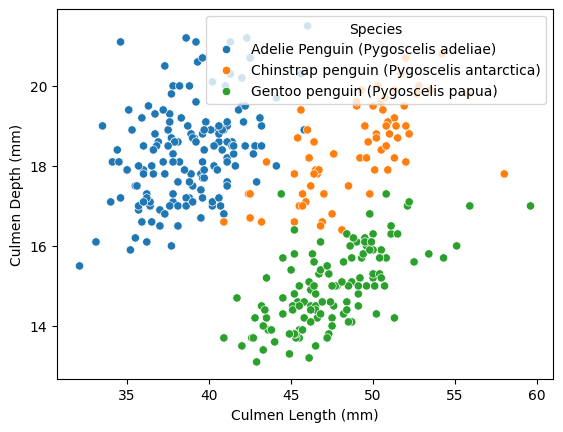

In [570]:
sns.scatterplot(x=df["Culmen Length (mm)"],y=df["Culmen Depth (mm)"],hue=df["Species"])
plt.show()

In [571]:
df.head()

,Species,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
0,Adelie Penguin (Pygoscelis adeliae),39.1,18.7,181.0,3750.0
1,Adelie Penguin (Pygoscelis adeliae),39.5,17.4,186.0,3800.0
2,Adelie Penguin (Pygoscelis adeliae),40.3,18.0,195.0,3250.0
4,Adelie Penguin (Pygoscelis adeliae),36.7,19.3,193.0,3450.0
5,Adelie Penguin (Pygoscelis adeliae),39.3,20.6,190.0,3650.0


In [572]:
df.columns

Index(['Species', 'Culmen Length (mm)', 'Culmen Depth (mm)',
       'Flipper Length (mm)', 'Body Mass (g)'],
      dtype='str')

In [573]:
X = df.drop("Species",axis=1).values

In [574]:
X

array([[  39.1,   18.7,  181. , 3750. ],
       [  39.5,   17.4,  186. , 3800. ],
       [  40.3,   18. ,  195. , 3250. ],
       ...,
       [  50.4,   15.7,  222. , 5750. ],
       [  45.2,   14.8,  212. , 5200. ],
       [  49.9,   16.1,  213. , 5400. ]], shape=(342, 4))

In [575]:
y = (df['Species']).values

In [576]:
y

<StringArray>
['Adelie Penguin (Pygoscelis adeliae)', 'Adelie Penguin (Pygoscelis adeliae)',
 'Adelie Penguin (Pygoscelis adeliae)', 'Adelie Penguin (Pygoscelis adeliae)',
 'Adelie Penguin (Pygoscelis adeliae)', 'Adelie Penguin (Pygoscelis adeliae)',
 'Adelie Penguin (Pygoscelis adeliae)', 'Adelie Penguin (Pygoscelis adeliae)',
 'Adelie Penguin (Pygoscelis adeliae)', 'Adelie Penguin (Pygoscelis adeliae)',
 ...
   'Gentoo penguin (Pygoscelis papua)',   'Gentoo penguin (Pygoscelis papua)',
   'Gentoo penguin (Pygoscelis papua)',   'Gentoo penguin (Pygoscelis papua)',
   'Gentoo penguin (Pygoscelis papua)',   'Gentoo penguin (Pygoscelis papua)',
   'Gentoo penguin (Pygoscelis papua)',   'Gentoo penguin (Pygoscelis papua)',
   'Gentoo penguin (Pygoscelis papua)',   'Gentoo penguin (Pygoscelis papua)']
Length: 342, dtype: str

In [577]:
# Label-encoding kullanmalıyız.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [578]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [579]:
y_test

array([0, 0, 2, 2, 1, 0, 1, 2, 1, 1, 0, 2, 1, 2, 2, 2, 0, 0, 2, 2, 1, 2,
       2, 0, 0, 0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 0, 2, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 2, 0, 0, 1, 0, 2, 1, 0, 1, 0, 2, 2, 1, 2, 2, 1, 2,
       0, 0, 2])

In [580]:
pd.DataFrame(y_test).value_counts()
"""Adelie Penguin (Pygoscelis adeliae)          151
Gentoo penguin (Pygoscelis papua)            123
Chinstrap penguin (Pygoscelis antarctica)     68
Buradaki orana yakın dagılmıs stratify = y parametresi yüzünden"""

'Adelie Penguin (Pygoscelis adeliae)          151\nGentoo penguin (Pygoscelis papua)            123\nChinstrap penguin (Pygoscelis antarctica)     68\nBuradaki orana yakın dagılmıs stratify = y parametresi yüzünden'

In [581]:
X_train = torch.tensor(X_train,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.long)
y_test = torch.tensor(y_test,dtype=torch.long)

In [582]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

torch.Size([273, 4]) torch.Size([69, 4])
torch.Size([273]) torch.Size([69])


In [583]:
from torch import nn

class PenguenClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(4,16),
            nn.ReLU(),
            nn.Linear(16,16),
            nn.ReLU(),
            nn.Linear(16,3) 
        )

    def forward(self,x):
        return self.linear_layer_stack(x)

In [584]:
model = PenguenClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),lr=0.01)

In [585]:
from torchmetrics.classification import MulticlassAccuracy
accuracy = MulticlassAccuracy(num_classes=3)

In [586]:
epochs = 2000
for epoch in range(epochs):
    
    model.train()
    
    logits = model(X_train)
    loss = loss_fn(logits,y_train)

    preds = torch.softmax(logits,dim=1).argmax(dim=1)
    acc = accuracy(preds,y_train).item() * 100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits,y_test)

        test_preds = torch.softmax(test_logits,dim=1).argmax(dim=1)
        test_acc = accuracy(test_preds,y_test).item() * 100

    if epoch % 100 == 0:
        print(f"Epoch: {epoch}, train loss: {loss}, train accuracy: {acc}, test loss: {test_loss}, test accuracy: {test_acc}")

Epoch: 0, train loss: 397.9015808105469, train accuracy: 33.33333432674408, test loss: 240.06716918945312, test accuracy: 33.33333432674408
Epoch: 100, train loss: 0.8802965879440308, train accuracy: 54.9530565738678, test loss: 0.8695626258850098, test accuracy: 58.44444036483765
Epoch: 200, train loss: 0.7787160873413086, train accuracy: 56.929218769073486, test loss: 0.7651211023330688, test accuracy: 60.88888645172119
Epoch: 300, train loss: 0.6943150758743286, train accuracy: 58.306628465652466, test loss: 0.6738195419311523, test accuracy: 60.88888645172119
Epoch: 400, train loss: 0.6156197190284729, train accuracy: 59.97638702392578, test loss: 0.5802029967308044, test accuracy: 60.88888645172119
Epoch: 500, train loss: 0.5555912256240845, train accuracy: 59.84874963760376, test loss: 0.5012820959091187, test accuracy: 87.07936406135559
Epoch: 600, train loss: 0.48706021904945374, train accuracy: 63.208985328674316, test loss: 0.42289257049560547, test accuracy: 95.5555558204650

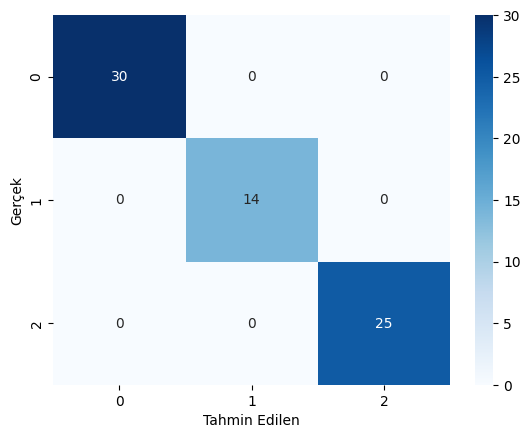

In [587]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
with torch.inference_mode():
    y_preds = model(X_test).argmax(dim=1)
    
cm = confusion_matrix(y_test.cpu(), y_preds.cpu())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.show()

In [ ]:
# Modeli kaydedelim. Amaç bir websitesinde göstermek
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True) # Daha önce varsa yaratmayalım diye var olduğunu da biliyoruzç.

MODEL_NAME = "penguen_classifier_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
print(MODEL_SAVE_PATH) # dOĞRU KONUMDAYIZ KAYDEDEBİLİRİZ

torch.save(obj=model.state_dict(),f=MODEL_SAVE_PATH) # ASlında state_dict'teki weightsleri kaydediyoruz.

models\penguen_classifier_model.pth
